# Analysis of DNS HTTPS RR Queries

The goal of this report is to help inform the decision of enabling the HTTPS RR or ECH in networking libraries by default.

It queries DNS for the A, AAAA and HTTPS resource records of the top N domains from the Tranco list.
It then analyzes the performance of the HTTPS resource records.

## Set up

In [1]:
topN = 100
numQueries = 1

In [10]:
!go run . -workspace ../workspace -topN {topN} -numQueries {numQueries}

time=2026-02-27T21:25:43.937Z level=INFO msg="Found Tranco list" path=/usr/local/google/home/fortuna/code/ech-research/workspace/tranco_7NZ4X-1m.csv.zip
time=2026-02-27T21:25:43.938Z level=INFO msg="Analyzing domain" rank=1 run=1 name=google.com
time=2026-02-27T21:25:43.938Z level=INFO msg="Analyzing domain" rank=2 run=1 name=mail.ru
time=2026-02-27T21:25:43.938Z level=INFO msg="Analyzing domain" rank=3 run=1 name=microsoft.com
time=2026-02-27T21:25:43.939Z level=INFO msg="Analyzing domain" rank=4 run=1 name=facebook.com
time=2026-02-27T21:25:43.939Z level=INFO msg="Analyzing domain" rank=5 run=1 name=cloudflare.com
time=2026-02-27T21:25:43.952Z level=INFO msg="Analyzing domain" rank=6 run=1 name=googleapis.com
time=2026-02-27T21:25:43.953Z level=INFO msg="Analyzing domain" rank=7 run=1 name=dzen.ru
time=2026-02-27T21:25:43.954Z level=INFO msg="Analyzing domain" rank=8 run=1 name=amazonaws.com
time=2026-02-27T21:25:43.954Z level=INFO msg="Analyzing domain" rank=9 run=1 name=youtube.com

## Latency Analysis
The following cell dynamically loads the most recent query results and visualizes the DNS query latency (`duration_ms`) by query type (`A`, `AAAA`, `HTTPS`). It scales based on the number of domains and runs. It produces a Boxplot to check for outliers and interquartile range differences, and a Cumulative Distribution Function (CDF) plot for a fine-grained view of the latency distribution.

Loading data from: ../workspace/results-top100-n1.csv
Excluded 53 failed queries. Proceeding with 247 successful queries.
Dataset contains 84 unique domains and 1 runs.


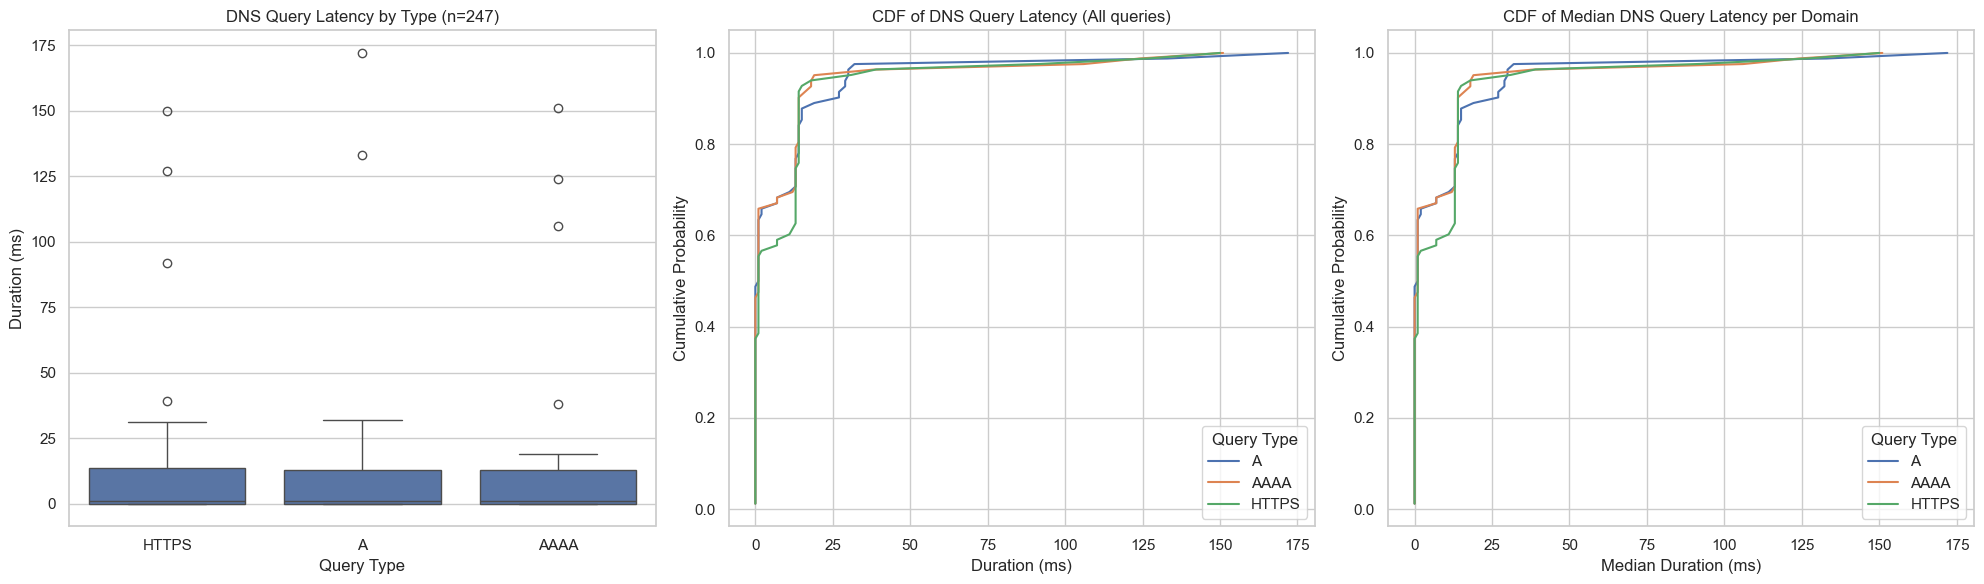


Summary Statistics of Latency (ms):


,count,mean,std,min,25%,50%,75%,max
query_type,,,,,,,,
A,82.0,9.463415,24.685276,0.0,0.0,1.0,13.0,172.0
AAAA,82.0,9.292683,24.448226,0.0,0.0,1.0,13.0,151.0
HTTPS,83.0,10.421687,23.709173,0.0,0.0,1.0,13.5,150.0


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Explicitly use the file generated in the previous step
latest_file = f'../workspace/results-top{topN}-n{numQueries}.csv'

if not os.path.exists(latest_file):
    raise FileNotFoundError(f"Could not find the expected results file: {latest_file}")

print(f"Loading data from: {latest_file}")

# Load the data
df = pd.read_csv(latest_file)

# Exclude failed queries (e.g. TIMEOUT)
df_success = df[df['error'].isna()].copy()
print(f"Excluded {len(df) - len(df_success)} failed queries. Proceeding with {len(df_success)} successful queries.")

# Extract number of domains and runs from filename or data
num_domains = df_success['rank'].nunique()
num_runs = df_success['run'].nunique()
print(f"Dataset contains {num_domains} unique domains and {num_runs} runs.")

# Configure aesthetics
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Boxplot
sns.boxplot(data=df_success, x='query_type', y='duration_ms', ax=axes[0])
axes[0].set_title(f'DNS Query Latency by Type (n={len(df_success)})')
axes[0].set_ylabel('Duration (ms)')
axes[0].set_xlabel('Query Type')

# CDF Plot of all queries
for qt, group in df_success.groupby('query_type'):
    x = np.sort(group['duration_ms'])
    y = np.arange(1, len(x) + 1) / len(x)
    axes[1].plot(x, y, label=qt)

axes[1].set_title('CDF of DNS Query Latency (All queries)')
axes[1].set_xlabel('Duration (ms)')
axes[1].set_ylabel('Cumulative Probability')
axes[1].legend(title='Query Type')

# CDF of median latency per domain
median_df = df_success.groupby(['domain', 'query_type'])['duration_ms'].median().reset_index()
for qt, group in median_df.groupby('query_type'):
    x = np.sort(group['duration_ms'])
    y = np.arange(1, len(x) + 1) / len(x)
    axes[2].plot(x, y, label=qt)

axes[2].set_title('CDF of Median DNS Query Latency per Domain')
axes[2].set_xlabel('Median Duration (ms)')
axes[2].set_ylabel('Cumulative Probability')
axes[2].legend(title='Query Type')

plt.tight_layout()
plt.show()

# Print summary statistics
summary_stats = df_success.groupby('query_type')['duration_ms'].describe()
print("\nSummary Statistics of Latency (ms):")
display(summary_stats)

## Slow Queries Analysis

The following table shows the top 20 slowest queries across all runs.

In [12]:
# Identify the slowest queries among the successful ones
slow_queries = df_success.sort_values(by='duration_ms', ascending=False).head(20)

print("\nTop 20 Slowest Successful Queries:")
display(slow_queries[['domain', 'query_type', 'duration_ms', 'nameservers']].reset_index(drop=True))


Top 20 Slowest Successful Queries:


,domain,query_type,duration_ms,nameservers
0,ripn.net,A,172,"[""a.dns.ripn.net."",""b.dns.ripn.net."",""d.dns.ri..."
1,ripn.net,AAAA,151,"[""a.dns.ripn.net."",""b.dns.ripn.net."",""d.dns.ri..."
2,ripn.net,HTTPS,150,"[""a.dns.ripn.net."",""b.dns.ripn.net."",""d.dns.ri..."
3,nic.ru,A,133,"[""ns5.nic.ru."",""ns6.nic.ru."",""ns9.nic.ru.""]"
4,nic.ru,HTTPS,127,"[""ns5.nic.ru."",""ns6.nic.ru."",""ns9.nic.ru.""]"
5,mail.ru,AAAA,124,"[""ns1.mail.ru."",""ns2.mail.ru.""]"
6,gandi.net,AAAA,106,"[""dns0.gandi.net."",""dns1.gandi.net."",""dns2.gan..."
7,gandi.net,HTTPS,92,"[""dns0.gandi.net."",""dns1.gandi.net."",""dns2.gan..."
8,workers.dev,HTTPS,39,"[""clyde.ns.cloudflare.com."",""sofia.ns.cloudfla..."
9,e2ro.com,AAAA,38,"[""ns-1269.awsdns-30.org."",""ns-1903.awsdns-45.c..."


## Failed Queries Analysis

The following section analyzes the queries that failed to resolve, detailing the error types and affected domains.

In [13]:
# Analyze failed queries
df_failed = df[df['error'].notna()].copy()

print(f"Total Failed Queries: {len(df_failed)} out of {len(df)} ({len(df_failed)/len(df)*100:.2f}%)")

if not df_failed.empty:
    print("\nBreakdown of Errors by Query Type:")
    error_summary = df_failed.groupby(['query_type', 'error']).size().reset_index(name='count')
    display(error_summary)
    
    print("\nFailed Domains (Success vs Failure for each RR):")
    failed_domains = df_failed['domain'].unique()
    df_failed_domains = df[df['domain'].isin(failed_domains)].copy()
    df_failed_domains['status'] = df_failed_domains['error'].fillna('Success')
    
    df_status = df_failed_domains.groupby(['rank', 'domain', 'nameservers', 'query_type'])['status'].apply(lambda x: ' / '.join(x.astype(str).unique())).unstack()
    df_status = df_status.reset_index().sort_values('rank', ascending=True)
    df_status.columns.name = None  # Remove the 'query_type' label from the columns axis
    
    cols = ['rank', 'domain', 'nameservers']
    for qt in ['A', 'AAAA', 'HTTPS']:
        if qt in df_status.columns:
            cols.append(qt)
            
    for col in df_status.columns:
        if col not in cols:
            cols.append(col)
            
    df_status = df_status[cols].fillna('-')
    display(df_status.reset_index(drop=True))
else:
    print("No failed queries detected in this dataset.")

Total Failed Queries: 53 out of 300 (17.67%)

Breakdown of Errors by Query Type:


,query_type,error,count
0,A,query failed: ETIMEDOUT,18
1,AAAA,query failed: ETIMEDOUT,18
2,HTTPS,query failed: ETIMEDOUT,17



Failed Domains (Success vs Failure for each RR):


,rank,domain,nameservers,A,AAAA,HTTPS
0,43,ctldl.windowsupdate.com,"[""ns1.qdr.qwilted-cds.cqloud.com."",""ns2.qdr.qw...",Success,query failed: ETIMEDOUT,Success
1,44,fastly.net,"[""ns1.fastly.net."",""ns2.fastly.net."",""ns3.fast...",query failed: ETIMEDOUT,query failed: ETIMEDOUT,Success
2,45,netflix.com,"[""ns-1372.awsdns-43.org."",""ns-1984.awsdns-56.c...",query failed: ETIMEDOUT,query failed: ETIMEDOUT,query failed: ETIMEDOUT
3,46,wordpress.org,"[""ns1.wordpress.org."",""ns2.wordpress.org."",""ns...",query failed: ETIMEDOUT,query failed: ETIMEDOUT,query failed: ETIMEDOUT
4,47,appsflyersdk.com,"[""ns-1430.awsdns-50.org."",""ns-1786.awsdns-31.c...",query failed: ETIMEDOUT,query failed: ETIMEDOUT,query failed: ETIMEDOUT
5,48,digicert.com,"[""ns20.digicertdns.com."",""ns21.digicertdns.com...",query failed: ETIMEDOUT,query failed: ETIMEDOUT,query failed: ETIMEDOUT
6,49,apple-dns.net,"[""a.ns.apple.com."",""b.ns.apple.com."",""c.ns.app...",query failed: ETIMEDOUT,query failed: ETIMEDOUT,query failed: ETIMEDOUT
7,50,youtu.be,"[""ns1.google.com."",""ns2.google.com."",""ns3.goog...",query failed: ETIMEDOUT,Success,query failed: ETIMEDOUT
8,51,icloud.com,"[""a.ns.apple.com."",""b.ns.apple.com."",""c.ns.app...",query failed: ETIMEDOUT,query failed: ETIMEDOUT,query failed: ETIMEDOUT
9,52,aaplimg.com,"[""a.ns.apple.com."",""b.ns.apple.com."",""c.ns.app...",query failed: ETIMEDOUT,query failed: ETIMEDOUT,query failed: ETIMEDOUT
